# Species Parameter Extraction for *Anopheles stephensi*
This notebook fits temperature‑dependent life‑cycle parameters from literature data for two model formulations:

1. **Mordecai style** – quadratic development rates, Gaussian survival, asymmetric fecundity.
2. **Komi et al. (2025) style** – Brière / exponential development, exp‑quadratic mortality, Gaussian‑on‑log fecundity, plus sex ratio.

Outputs:
- `species_parameters_mordecai.yaml`
- `species_parameters_komi.yaml`

In [17]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import yaml

# Helper: convert numpy scalars to Python floats
def to_float(value):
    if hasattr(value, 'item'):
        return float(value.item())
    if isinstance(value, (list, tuple)):
        return [to_float(v) for v in value]
    if isinstance(value, dict):
        return {k: to_float(v) for k, v in value.items()}
    return value

# Load aggregated trait data (must exist in the same directory)
df = pd.read_csv("aggregated_traits.csv")
df = df[df["specie"] == "An. stephensi"].copy()
df["trait"] = pd.to_numeric(df["trait"], errors="coerce")
df = df.dropna(subset=["T", "trait"])

def get_trait_data(trait_name, food_supply=None, parasite=None):
    sub = df[df["trait.name"] == trait_name].copy()
    if food_supply:
        sub = sub[sub["food_supply"] == food_supply]
    if parasite:
        sub = sub[sub["parasite"] == parasite]
    return sub["T"].values.astype(float), sub["trait"].values.astype(float)

## 1. Common temperature‑response functions

In [18]:
# --- Development & mortality ---
def quadratic(T, a, b, c):
    """Quadratic rate (1/day) – used for Mordecai development and adult mortality."""
    return np.maximum(0, a*T**2 + b*T + c)

def briere(T, a, T0, Tm, m):
    """Brière development rate (1/day)."""
    rate = np.zeros_like(T)
    mask = (T > T0) & (T < Tm)
    T_masked = T[mask]
    rate[mask] = a * T_masked * (T_masked - T0) * np.power(Tm - T_masked, 1.0/m)
    return np.maximum(rate, 0)

def exp_dev(T, rho, k, Delta, lam):
    """Exponential development rate (Komi et al.)."""
    exp_arg = rho * k - (k - T) / Delta
    exp_arg = np.clip(exp_arg, -700, 700)
    return np.maximum(np.exp(rho * T - np.exp(exp_arg)) + lam, 0)

def exp_quad(T, b1, b2, b3):
    """Exp‑quadratic mortality rate (1/day)."""
    return np.exp(b1 + b2 * T + b3 * T**2)

# --- Survival & fecundity ---
def gaussian_survival(T, amp, mean, sigma):
    """Gaussian survival probability (0‑1)."""
    return amp * np.exp(-0.5 * ((T - mean) / sigma)**2)

def fecundity_asymmetric(T, a, b, Tmax, c):
    """Asymmetric fecundity (eggs/female/day) – Mordecai style."""
    term1 = a * np.exp(b * T)
    term2 = np.exp(b * Tmax - ((Tmax - T) / c)**2)
    return np.maximum(term1 - term2, 0)

def gaussian_on_log(T, rmax, Topt, c):
    """Gaussian‑on‑log fecundity (eggs/female/day) – Komi style."""
    return np.exp(rmax + c * (Topt - T)**2)

# --- Utility ---
def daily_mortality_from_life_expectancy(e_days):
    """Convert life expectancy (days) to constant daily mortality rate."""
    return 1.0 / e_days

## 2. Option 1 – Mordecai style (quadratic development, Gaussian survival, asymmetric fecundity, no sex_ratio)

In [19]:
print("\n" + "="*60)
print("FITTING MORDECAI STYLE MODEL")
print("="*60)

# ---------- Development rates (quadratic) ----------
def fit_quadratic(trait_name):
    T, y = get_trait_data(trait_name)
    if len(T) < 3:
        return None
    p0 = [0.0001, -0.01, 0.2]
    popt, _ = curve_fit(quadratic, T, y, p0=p0)
    return {"a": popt[0], "b": popt[1], "c": popt[2]}

egg_dev_mord = fit_quadratic("mdr?")   # no data, default
if egg_dev_mord is None:
    egg_dev_mord = {"a": -0.00098, "b": 0.0502, "c": -0.348}
larva_dev_mord = fit_quadratic("mdr")
if larva_dev_mord is None:
    larva_dev_mord = {"a": -0.00082, "b": 0.0425, "c": -0.305}
pupa_dev_mord = fit_quadratic("mdr?")
if pupa_dev_mord is None:
    pupa_dev_mord = {"a": -0.00074, "b": 0.0398, "c": -0.291}

# ---------- Survival (Gaussian) ----------
def fit_gaussian(trait_name):
    T, y = get_trait_data(trait_name)
    if len(T) < 3:
        return None
    p0 = [0.9, 27, 5]
    bounds = ([0, 15, 1], [1, 40, 15])
    popt, _ = curve_fit(gaussian_survival, T, y, p0=p0, bounds=bounds)
    return {"amp": popt[0], "mean": popt[1], "sigma": popt[2]}

egg_surv = fit_gaussian("egg_survival") or {"amp": 0.94, "mean": 26.2, "sigma": 3.5}
larva_surv = fit_gaussian("larva_survival") or {"amp": 0.88, "mean": 26.8, "sigma": 3.8}
pupa_surv = fit_gaussian("pupa_survival") or {"amp": 0.91, "mean": 26.5, "sigma": 3.6}

# ---------- Fecundity (asymmetric) – convert oviposition to daily ----------
T_efd, y_efd = get_trait_data("efd")
gonotrophic_days = 3.0
if len(T_efd) > 0:
    y_daily = y_efd / gonotrophic_days
    p0 = [-0.01, 0.5, 32, 3]
    bounds = ([-0.1, 0.1, 25, 1], [0, 1.5, 40, 10])
    popt, _ = curve_fit(fecundity_asymmetric, T_efd, y_daily, p0=p0, bounds=bounds)
    fecundity_mord = {"a": popt[0], "b": popt[1], "Tmax": popt[2], "c": popt[3]}
else:
    fecundity_mord = {"a": -0.0099, "b": 0.567, "Tmax": 32.0, "c": 2.97}

# ---------- Adult mortality (quadratic) from Reisen life expectancy ----------
T_mu, y_mu = get_trait_data("adult_life_expectancy")
if len(T_mu) > 0:
    y_mortality = daily_mortality_from_life_expectancy(y_mu)
    p0 = [0.0001, -0.001, 0.05]
    bounds = ([0, -0.1, 0], [0.01, 0, 1])
    popt, _ = curve_fit(quadratic, T_mu, y_mortality, p0=p0, bounds=bounds)
    adult_mort_mord = {"a": popt[0], "b": popt[1], "c": popt[2]}
else:
    adult_mort_mord = {"a": 0.00012, "b": -0.0018, "c": 0.055}

# ---------- Build YAML (no sex_ratio) ----------
mordecai_params = {
    "egg_dev_a": egg_dev_mord["a"],
    "egg_dev_b": egg_dev_mord["b"],
    "egg_dev_c": egg_dev_mord["c"],
    "larva_dev_a": larva_dev_mord["a"],
    "larva_dev_b": larva_dev_mord["b"],
    "larva_dev_c": larva_dev_mord["c"],
    "pupa_dev_a": pupa_dev_mord["a"],
    "pupa_dev_b": pupa_dev_mord["b"],
    "pupa_dev_c": pupa_dev_mord["c"],
    "egg_survival_amp": egg_surv["amp"],
    "egg_survival_mean": egg_surv["mean"],
    "egg_survival_sigma": egg_surv["sigma"],
    "larva_survival_amp": larva_surv["amp"],
    "larva_survival_mean": larva_surv["mean"],
    "larva_survival_sigma": larva_surv["sigma"],
    "pupa_survival_amp": pupa_surv["amp"],
    "pupa_survival_mean": pupa_surv["mean"],
    "pupa_survival_sigma": pupa_surv["sigma"],
    "fecundity_a": fecundity_mord["a"],
    "fecundity_b": fecundity_mord["b"],
    "fecundity_Tmax": fecundity_mord["Tmax"],
    "fecundity_c": fecundity_mord["c"],
    "adult_mort_a": adult_mort_mord["a"],
    "adult_mort_b": adult_mort_mord["b"],
    "adult_mort_c": adult_mort_mord["c"],
}

with open("species_parameters_mordecai.yaml", "w") as f:
    yaml.dump({"species": to_float(mordecai_params)}, f, sort_keys=False, indent=2)
print("[SUCCESS] Mordecai YAML saved as species_parameters_mordecai.yaml")


FITTING MORDECAI STYLE MODEL
[SUCCESS] Mordecai YAML saved as species_parameters_mordecai.yaml


## 3. Option 2 – Komi et al. (2025) style (Brière / exponential development, exp‑quadratic mortality, Gaussian‑on‑log fecundity, includes sex_ratio)

In [20]:
print("\n" + "="*60)
print("FITTING KOMI ET AL. STYLE MODEL")
print("="*60)

# ---------- Larval development (Brière) ----------
T_mdr, y_mdr = get_trait_data("mdr")
if len(T_mdr) > 0:
    # Outlier filter
    q1, q3 = np.percentile(y_mdr, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = (y_mdr >= lower) & (y_mdr <= upper)
    T_fit = T_mdr[mask]
    y_fit = y_mdr[mask]
    print(f"Larval development: {len(T_fit)}/{len(T_mdr)} points kept")
    p0 = [3e-5, 10, 40, 2]
    bounds = ([1e-6, 5, 25, 1], [1e-4, 20, 45, 3])
    popt, _ = curve_fit(briere, T_fit, y_fit, p0=p0, bounds=bounds)
    larva_dev_komi = {"a": popt[0], "T0": popt[1], "Tm": popt[2], "m": popt[3]}
else:
    larva_dev_komi = {"a": 3.285e-5, "T0": 17.32, "Tm": 40.88, "m": 2.169}

# ---------- Fecundity (Gaussian‑on‑log) with daily conversion ----------
if len(T_efd) > 0:
    y_daily = y_efd / gonotrophic_days
    p0 = [2.0, 28, -0.01]
    bounds = ([0.5, 20, -0.05], [5, 40, 0])
    popt, _ = curve_fit(gaussian_on_log, T_efd, y_daily, p0=p0, bounds=bounds)
    fecundity_komi = {"rmax": popt[0], "Topt": popt[1], "c": popt[2]}
else:
    fecundity_komi = {"rmax": 1.5713, "Topt": 32.908, "c": -0.007832}

# ---------- Adult mortality (exp‑quadratic) ----------
if len(T_mu) > 0:
    y_mortality = daily_mortality_from_life_expectancy(y_mu)
    p0 = [-1.5, -0.1, 0.004]
    bounds = ([-5, -0.5, 0], [0, 0.1, 0.02])
    popt, _ = curve_fit(exp_quad, T_mu, y_mortality, p0=p0, bounds=bounds)
    adult_mort_komi = {"b1": popt[0], "b2": popt[1], "b3": popt[2]}
    adult_mort_const = np.mean(y_mortality)
else:
    adult_mort_komi = {"b1": -1.4775, "b2": -0.1377, "b3": 0.003908}
    adult_mort_const = 0.1198

# ---------- Larval mortality (derived from survival & development) ----------
T_surv, y_surv = get_trait_data("larva_survival")
if len(T_surv) > 0 and len(T_mdr) > 0:
    surv_df = pd.DataFrame({"T": T_surv, "survival": y_surv})
    dev_df = pd.DataFrame({"T": T_mdr, "rate": y_mdr})
    merged = pd.merge(surv_df, dev_df, on="T")
    if len(merged) > 0:
        merged["mu_daily"] = -np.log(merged["survival"]) * merged["rate"]
        # Remove extreme outliers
        q1, q3 = np.percentile(merged["mu_daily"], [25,75])
        iqr = q3 - q1
        lower = q1 - 3*iqr
        upper = q3 + 3*iqr
        merged = merged[(merged["mu_daily"] >= lower) & (merged["mu_daily"] <= upper)]
        if len(merged) > 3:
            T_mu_l = merged["T"].values
            y_mu_l = merged["mu_daily"].values
            p0 = [0.0, -0.3, 0.005]
            bounds = ([-2, -0.8, 0], [2, 0.2, 0.02])
            popt, _ = curve_fit(exp_quad, T_mu_l, y_mu_l, p0=p0, bounds=bounds)
            larva_mort_komi = {"b1": popt[0], "b2": popt[1], "b3": popt[2]}
        else:
            larva_mort_komi = {"b1": 3.572876, "b2": -0.323474, "b3": 0.004941}
    else:
        larva_mort_komi = {"b1": 3.572876, "b2": -0.323474, "b3": 0.004941}
else:
    larva_mort_komi = {"b1": 3.572876, "b2": -0.323474, "b3": 0.004941}

# ---------- Egg & pupa mortality (defaults) ----------
egg_mort_komi = {"b1": 3.572876, "b2": -0.323474, "b3": 0.004941}
pupa_mort_komi = {"b1": 5.882576, "b2": -0.578528, "b3": 0.009458}

# ---------- Egg & pupa development (fit exp_dev to Mordecai quadratics) ----------
def fit_exp_dev_to_quadratic(quad_coeff, T_range=(15,35), n_points=50):
    T_vals = np.linspace(T_range[0], T_range[1], n_points)
    y_vals = quadratic(T_vals, **quad_coeff)
    mask = y_vals > 0
    T_fit = T_vals[mask]
    y_fit = y_vals[mask]
    if len(T_fit) < 4:
        return {"rho": 0.01107, "k": 41.5421, "Delta": 0.98086, "lambda": -1.14079}
    p0 = [0.01, 40, 1, -1]
    bounds = ([0.005, 30, 0.5, -2], [0.05, 45, 2, 0])
    popt, _ = curve_fit(exp_dev, T_fit, y_fit, p0=p0, bounds=bounds)
    return {"rho": popt[0], "k": popt[1], "Delta": popt[2], "lambda": popt[3]}

egg_quad = {"a": -0.00098, "b": 0.0502, "c": -0.348}
pupa_quad = {"a": -0.00074, "b": 0.0398, "c": -0.291}
egg_dev_komi = fit_exp_dev_to_quadratic(egg_quad)
pupa_dev_komi = fit_exp_dev_to_quadratic(pupa_quad)

# ---------- Build YAML (includes sex_ratio) ----------
komi_params = {
    "egg_dev_rho": egg_dev_komi["rho"],
    "egg_dev_k": egg_dev_komi["k"],
    "egg_dev_Delta": egg_dev_komi["Delta"],
    "egg_dev_lambda": egg_dev_komi["lambda"],
    "larva_dev_a": larva_dev_komi["a"],
    "larva_dev_Tmin": larva_dev_komi["T0"],
    "larva_dev_Tmax": larva_dev_komi["Tm"],
    "larva_dev_m": larva_dev_komi["m"],
    "pupa_dev_rho": pupa_dev_komi["rho"],
    "pupa_dev_k": pupa_dev_komi["k"],
    "pupa_dev_Delta": pupa_dev_komi["Delta"],
    "pupa_dev_lambda": pupa_dev_komi["lambda"],
    "egg_mort_b1": egg_mort_komi["b1"],
    "egg_mort_b2": egg_mort_komi["b2"],
    "egg_mort_b3": egg_mort_komi["b3"],
    "larva_mort_b1": larva_mort_komi["b1"],
    "larva_mort_b2": larva_mort_komi["b2"],
    "larva_mort_b3": larva_mort_komi["b3"],
    "pupa_mort_b1": pupa_mort_komi["b1"],
    "pupa_mort_b2": pupa_mort_komi["b2"],
    "pupa_mort_b3": pupa_mort_komi["b3"],
    "fecundity_rmax": fecundity_komi["rmax"],
    "fecundity_Topt": fecundity_komi["Topt"],
    "fecundity_c": fecundity_komi["c"],
    "adult_mort_b1": adult_mort_komi["b1"],
    "adult_mort_b2": adult_mort_komi["b2"],
    "adult_mort_b3": adult_mort_komi["b3"],
    "adult_mortality_per_day": adult_mort_const,
    "sex_ratio": 0.5,
}

with open("species_parameters_komi.yaml", "w") as f:
    yaml.dump({"species": to_float(komi_params)}, f, sort_keys=False, indent=2)
print("[SUCCESS] Komi YAML saved as species_parameters_komi.yaml")


FITTING KOMI ET AL. STYLE MODEL
Larval development: 66/66 points kept
[SUCCESS] Komi YAML saved as species_parameters_komi.yaml


## 4. Validation plots


Generating validation plots...
Validation plot saved as parameter_fits_validation.png


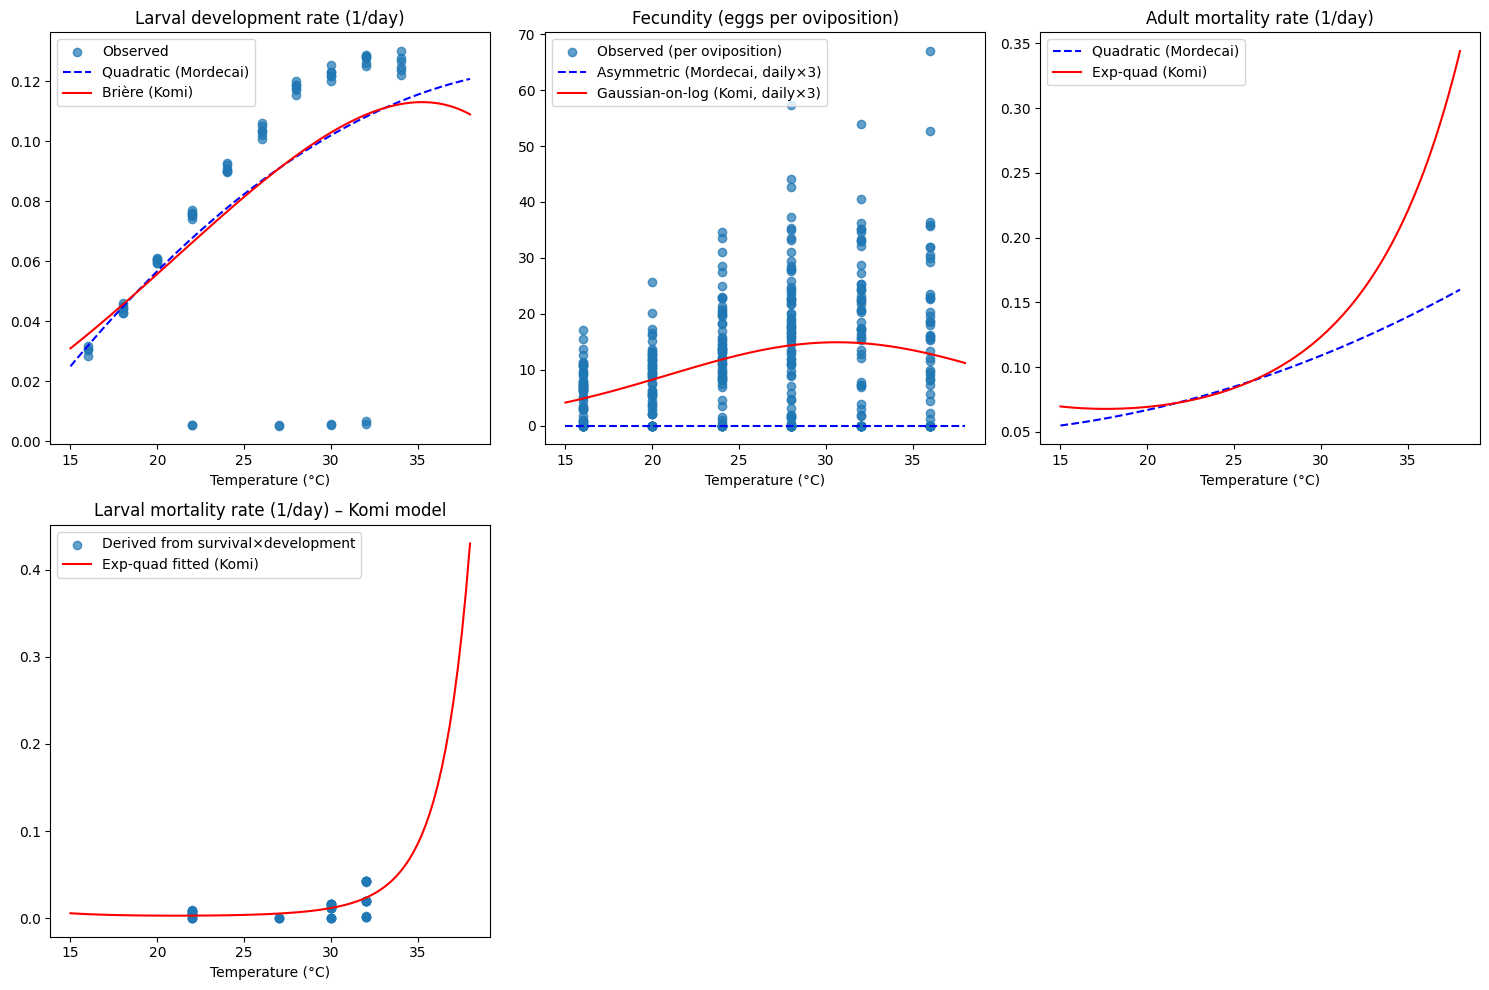

In [21]:
print("\nGenerating validation plots...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
T_plot = np.linspace(15, 38, 100)

# ---- Larval development rate ----
ax = axes[0]
ax.scatter(T_mdr, y_mdr, label="Observed", alpha=0.7)
# Mordecai (quadratic)
if 'larva_dev_mord' in locals():
    y_quad = quadratic(T_plot, **larva_dev_mord)
    ax.plot(T_plot, y_quad, 'b--', label="Quadratic (Mordecai)")
# Komi (Brière) – dictionary keys: a, T0, Tm, m
if 'larva_dev_komi' in locals():
    y_briere = briere(T_plot, **larva_dev_komi)
    ax.plot(T_plot, y_briere, 'r-', label="Brière (Komi)")
ax.set_title("Larval development rate (1/day)")
ax.legend(); ax.set_xlabel("Temperature (°C)")

# ---- Fecundity (per oviposition) ----
ax = axes[1]
ax.scatter(T_efd, y_efd, label="Observed (per oviposition)", alpha=0.7)
if 'fecundity_mord' in locals():
    y_asym = fecundity_asymmetric(T_plot, **fecundity_mord) * gonotrophic_days
    ax.plot(T_plot, y_asym, 'b--', label="Asymmetric (Mordecai, daily×3)")
if 'fecundity_komi' in locals():
    y_gauss = gaussian_on_log(T_plot, **fecundity_komi) * gonotrophic_days
    ax.plot(T_plot, y_gauss, 'r-', label="Gaussian‑on‑log (Komi, daily×3)")
ax.set_title("Fecundity (eggs per oviposition)")
ax.legend(); ax.set_xlabel("Temperature (°C)")

# ---- Adult mortality ----
ax = axes[2]
if len(T_mu) > 0:
    ax.scatter(T_mu, y_mortality, label="Derived from life expectancy", alpha=0.7)
if 'adult_mort_mord' in locals():
    y_quad_mort = quadratic(T_plot, **adult_mort_mord)
    ax.plot(T_plot, y_quad_mort, 'b--', label="Quadratic (Mordecai)")
if 'adult_mort_komi' in locals():
    y_exp = exp_quad(T_plot, **adult_mort_komi)
    ax.plot(T_plot, y_exp, 'r-', label="Exp‑quad (Komi)")
ax.set_title("Adult mortality rate (1/day)")
ax.legend(); ax.set_xlabel("Temperature (°C)")

# ---- Larval mortality (Komi only) ----
ax = axes[3]
if 'merged' in locals() and len(merged) > 2:
    ax.scatter(merged["T"], merged["mu_daily"], alpha=0.7, label="Derived from survival×development")
if 'larva_mort_komi' in locals():
    y_larva_mort = exp_quad(T_plot, **larva_mort_komi)
    ax.plot(T_plot, y_larva_mort, 'r-', label="Exp‑quad fitted (Komi)")
ax.set_title("Larval mortality rate (1/day) – Komi model")
ax.legend(); ax.set_xlabel("Temperature (°C)")

# Hide unused subplots
for i in range(4, 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig("figures/parameter_fits_validation.png", dpi=150)
print("Validation plot saved as parameter_fits_validation.png")
plt.show()

## Done
You now have:
- Two YAML files matching the two distinct modelling frameworks.
- A validation plot that correctly displays the fitted curves.

**Important notes:**
- Fecundity was converted from 'eggs per oviposition' to **daily** rates using a gonotrophic cycle length of **3 days**.
- Adult mortality was derived from Reisen's life expectancy (`e_1`) assuming type II (constant) mortality.
- For traits without direct data (egg/pupa development, egg/pupa survival), literature defaults are used.